In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [ ]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [ ]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.167289,-0.562066,-1.011756,2.046451,0.626978,1
1,0.947381,-1.934004,-2.001192,0.616195,-0.013049,1
2,1.175573,-1.013828,1.480919,1.263523,1.641774,0
3,0.132022,0.793466,-1.101284,2.162783,1.868608,1
4,0.084626,-0.257023,0.166179,-1.074859,0.463815,0


In [ ]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [ ]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols].copy() # Explicitly create a copy to avoid SettingWithCopyWarning
  new_df['target'] = df['target']
  return new_df

In [ ]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [ ]:
import random # Add this line to import the random module
df1 = combined_sampling(df,0.5,0.5)

In [ ]:
df2 = combined_sampling(df,0.5,0.5)

In [ ]:
df3 = combined_sampling(df,0.5,0.5)

In [ ]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col4', 'target'], dtype='object')
Index(['col2', 'col5', 'target'], dtype='object')
Index(['col2', 'col1', 'target'], dtype='object')


In [ ]:
df3

,col2,col1,target
77,-0.646427,2.136529,0
19,-0.829401,0.980861,0
45,-0.343200,1.137526,0
33,-1.514778,1.069570,0
81,-1.238953,0.733288,0
3,0.793466,0.132022,1
60,-0.737457,0.359515,0
69,-0.773092,1.742927,0
13,1.105621,2.071226,0
49,-0.348021,2.417933,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [ ]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [ ]:
from sklearn.tree import plot_tree

[Text(0.44047619047619047, 0.9375, 'x[0] <= -2.323\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.39285714285714285, 0.8125, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.41666666666666663, 0.875, 'True  '),
 Text(0.4880952380952381, 0.8125, 'x[1] <= 0.936\ngini = 0.483\nsamples = 44\nvalue = [26, 18]'),
 Text(0.4642857142857143, 0.875, '  False'),
 Text(0.23809523809523808, 0.6875, 'x[1] <= -0.157\ngini = 0.496\nsamples = 22\nvalue = [10, 12]'),
 Text(0.14285714285714285, 0.5625, 'x[0] <= -1.252\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.09523809523809523, 0.4375, 'x[0] <= -1.683\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.047619047619047616, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.14285714285714285, 0.3125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.19047619047619047, 0.4375, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.3333333333333333, 0.5625, 'x[0] <= -0.233\ngini = 0.355\nsamples = 13\nvalue = [3, 10]'),
 Te

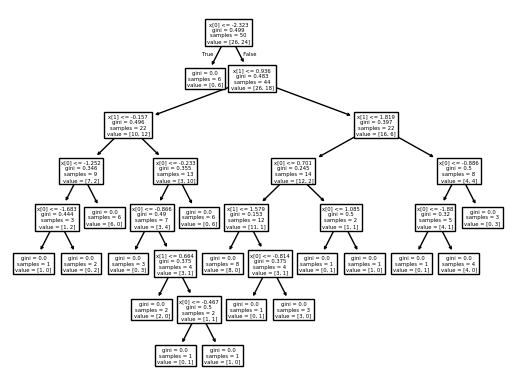

In [ ]:
plot_tree(clf1)

[Text(0.5769230769230769, 0.9375, 'x[0] <= -0.674\ngini = 0.449\nsamples = 50\nvalue = [17, 33]'),
 Text(0.38461538461538464, 0.8125, 'x[1] <= 2.051\ngini = 0.499\nsamples = 29\nvalue = [15.0, 14.0]'),
 Text(0.4807692307692307, 0.875, 'True  '),
 Text(0.3076923076923077, 0.6875, 'x[0] <= -1.273\ngini = 0.476\nsamples = 23\nvalue = [9, 14]'),
 Text(0.15384615384615385, 0.5625, 'x[0] <= -2.587\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.07692307692307693, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.23076923076923078, 0.4375, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.46153846153846156, 0.5625, 'x[1] <= -0.127\ngini = 0.444\nsamples = 12\nvalue = [8, 4]'),
 Text(0.38461538461538464, 0.4375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.5384615384615384, 0.4375, 'x[1] <= 0.266\ngini = 0.494\nsamples = 9\nvalue = [5, 4]'),
 Text(0.46153846153846156, 0.3125, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6153846153846154, 0.3125, 'x[0] <= -0.

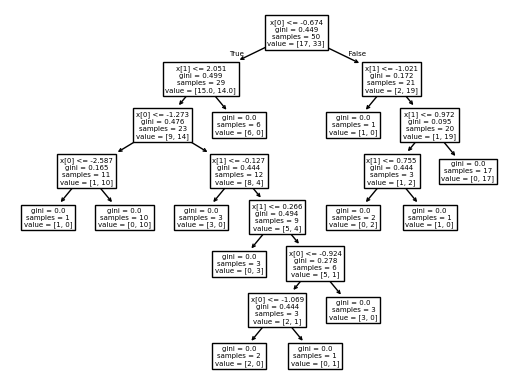

In [ ]:
plot_tree(clf2)

[Text(0.4642857142857143, 0.9166666666666666, 'x[0] <= -0.245\ngini = 0.449\nsamples = 50\nvalue = [33, 17]'),
 Text(0.2857142857142857, 0.75, 'x[0] <= -1.917\ngini = 0.245\nsamples = 35\nvalue = [30, 5]'),
 Text(0.375, 0.8333333333333333, 'True  '),
 Text(0.14285714285714285, 0.5833333333333334, 'x[1] <= 1.279\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.07142857142857142, 0.4166666666666667, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.21428571428571427, 0.4166666666666667, 'x[1] <= 2.272\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.14285714285714285, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2857142857142857, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.42857142857142855, 0.5833333333333334, 'x[1] <= 1.972\ngini = 0.064\nsamples = 30\nvalue = [29, 1]'),
 Text(0.35714285714285715, 0.4166666666666667, 'gini = 0.0\nsamples = 24\nvalue = [24, 0]'),
 Text(0.5, 0.4166666666666667, 'x[1] <= 2.11\ngini = 0.278\nsamples = 6\nvalue = [5, 1]

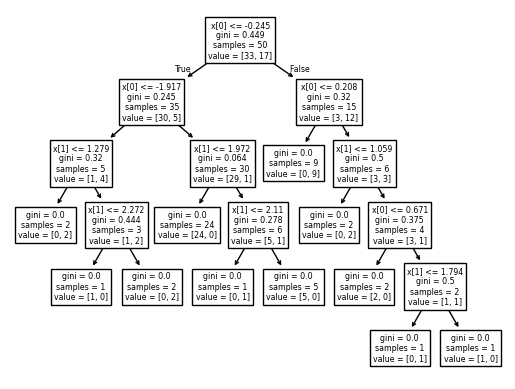

In [ ]:
plot_tree(clf3)

In [ ]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
92,0.581908,-0.935173,1.573965,0.740448,2.012064,0
38,1.676635,-2.993996,2.202921,3.017717,2.349592,0
24,1.021317,-2.103829,0.277578,1.838331,0.486199,1
34,-1.612089,-0.317506,-2.445864,0.390096,1.291971,1
13,2.071226,1.105621,-0.386629,0.946114,-1.844555,0
24,1.021317,-2.103829,0.277578,1.838331,0.486199,1
63,0.324643,-0.783660,1.217151,0.384488,1.725831,0
65,0.759825,-0.406193,-1.280575,1.987338,1.062417,1
56,2.932317,0.123738,1.414668,-0.003481,2.857485,1
8,1.175310,0.916369,-0.112311,-0.184074,-0.824495,0
